# Building a 2D image dataset with `miao`

`miao`'s `VolumeDataset` samples **3D** patches, but it is possible to create a 2D dataset by concatenating three axis-aligned `VolumeDataset`s with `patch_size`s `(1,P,P)`, `(P,1,P)`, and `(P,P,1)`.

The one thing that has to be added is a custom `collate_fn`. The three sub-datasets return tensors
with the singleton on different axes, so the default collate can't stack them. This notebook demonstrates how to do this.

In [1]:
import numpy as np
import torch
from torch.utils.data import ConcatDataset, DataLoader, default_collate

from miao import MiaoConfig, VolumeDataset, load_config

## 1. Start from an ordinary config

In [2]:
base = load_config("config.yaml")   # examples/config.yaml, next to this notebook

SPATIAL = "xyzt"
spatial_order = "".join(c for c in base.output_axes if c in SPATIAL)

print("output_axes  :", base.output_axes)
print("spatial order:", spatial_order)
print("patch_size   :", base.patch_size)
print("n_scales     :", base.n_scales)

output_axes  : lcxyz
spatial order: xyz
patch_size   : [128, 128, 128]
n_scales     : 3


`patch_size` is given in `output_axes` **spatial** order. Here `output_axes="lcxyz"`, so the spatial
order is `xyz` and `patch_size=[1, P, P]` puts the singleton on `x` — an *x-normal* slice, i.e. a `yz`
plane.

In [3]:
P = 128           # in-plane size
SAMPLES = 60      # total samples per epoch, split across the three orientations


def with_overrides(cfg: MiaoConfig, **updates) -> MiaoConfig:
    """Return a copy of `cfg` with `updates` applied, re-running pydantic validation."""
    data = cfg.model_dump()
    data.update(updates)
    return MiaoConfig(**data)


def plane_config(cfg: MiaoConfig, thin_axis: str, size: int, **updates) -> MiaoConfig:
    """Config for a one-voxel-thick patch, i.e. a plane normal to `thin_axis`."""
    patch = [1 if c == thin_axis else size for c in spatial_order]
    return with_overrides(cfg, patch_size=patch, **updates)


# One fixed isotropic resolution to start with, so each sample is a single plane (L = 1).
plane_base = with_overrides(
    base,
    resolutions=[[16, 16, 16]],
    resolution_sampling=None,      # `resolutions` and `resolution_sampling` are mutually exclusive
    samples_per_epoch=SAMPLES // 3,
)

for ax in spatial_order:
    print(f"thin axis {ax}: patch_size={plane_config(plane_base, ax, P).patch_size}")

thin axis x: patch_size=[1, 128, 128]
thin axis y: patch_size=[128, 1, 128]
thin axis z: patch_size=[128, 128, 1]


## 2. Three degenerate `VolumeDataset`s, one `ConcatDataset`

In [4]:
plane_datasets = {ax: VolumeDataset(plane_config(plane_base, ax, P)) for ax in spatial_order}
dataset = ConcatDataset(plane_datasets.values())

print(f"\nlen(dataset) = {len(dataset)}"
      f" = {' + '.join(str(len(d)) for d in plane_datasets.values())}")

VolumeDataset: 2 volume(s), random, 20 samples/epoch, patch_size=[1, 128, 128]
  [Jiefu Cerebellum FIB-SEM]
    image: axes='zyx', shape=[11402, 5666, 4808], dtype=uint8
    scale 0: resolution=[16.0, 16.0, 16.0] nanometer -> level 0 (voxel_size=[16.0, 16.0, 16.0], read [128, 128, 1] -> resample to [128, 128, 1])
    label: axes='zyx', shape=[11402, 5666, 4808], dtype=uint32 -> int64
    sampling: weight=0.50, center_range=[[1262, 1522, 1133], [5497, 4709, 4807]]
    normalize: uint8 -> [0, 1] (divide by dtype max)
  [H01 Human Cortex]
    image: axes='xyz', shape=[16384, 16384, 1024], dtype=uint8
    scale 0: resolution=[16.0, 16.0, 16.0] nanometer -> level 0 (voxel_size=[4.0, 4.0, 33.0], read [4, 512, 63] -> resample to [1, 128, 128])
    label: axes='xyz', shape=[8192, 8192, 1024], dtype=uint64 -> int64
    sampling: weight=0.50, center_range=[[2, 256, 31], [16382, 16128, 992]]
    normalize: uint8 -> [0, 1] (divide by dtype max)
  output: axes='lcxyz', tensor_shape=(L, C, X, Y, Z)


In [5]:
for ax, ds in plane_datasets.items():
    s = ds[0]
    extent = (s["bbox"][0, 1] - s["bbox"][0, 0]).tolist()
    print(f"thin axis {ax}  ({s['meta']['volume']})")
    print(f"    img   {tuple(s['img'].shape)}  {s['img'].dtype}"
          f"      label {tuple(s['label'].shape)}  {s['label'].dtype}")
    print(f"    bbox  {tuple(s['bbox'].shape)}      pixel_size {tuple(s['pixel_size'].shape)}")
    print(f"    physical extent ({spatial_order}) = {extent} nm"
          f"  -> thickness {extent[spatial_order.index(ax)]:g} nm")

thin axis x  (Jiefu Cerebellum FIB-SEM)
    img   (1, 1, 1, 128, 128)  torch.float32      label (1, 1, 128, 128)  torch.int64
    bbox  (1, 2, 3)      pixel_size (1, 3)
    physical extent (xyz) = [16.0, 2048.0, 2048.0] nm  -> thickness 16 nm
thin axis y  (Jiefu Cerebellum FIB-SEM)
    img   (1, 1, 128, 1, 128)  torch.float32      label (1, 128, 1, 128)  torch.int64
    bbox  (1, 2, 3)      pixel_size (1, 3)
    physical extent (xyz) = [2048.0, 16.0, 2048.0] nm  -> thickness 16 nm


thin axis z  (H01 Human Cortex)
    img   (1, 1, 128, 128, 1)  torch.float32      label (1, 128, 128, 1)  torch.int64
    bbox  (1, 2, 3)      pixel_size (1, 3)
    physical extent (xyz) = [2048.0, 2048.0, 33.0] nm  -> thickness 33 nm


## 3. A custom `collate_fn` that drops the singleton axis

In [7]:
def make_plane_collate(output_axes: str):
    """Collate 1-voxel-thick samples by squeezing away the singleton spatial axis.

    Adds two keys to the batch, one entry per sample: `normal_axis` (the dropped axis, e.g. "x") and
    `plane` (the two axes that survive, in `output_axes` order, e.g. "yz").
    """
    img_dim = {c: i for i, c in enumerate(output_axes) if c in SPATIAL}
    label_axes = output_axes.replace("c", "")   # labels are returned without a channel axis

    def collate(samples):
        squeezed, normals, planes = [], [], []
        for sample in samples:
            img = sample["img"]
            thin = [c for c, d in img_dim.items() if img.shape[d] == 1]
            if len(thin) != 1:
                raise ValueError(
                    f"expected exactly one singleton spatial axis in img of shape "
                    f"{tuple(img.shape)} (output_axes={output_axes!r}), found {thin or 'none'}"
                )
            axis = thin[0]
            sample = dict(sample)
            sample["img"] = img.squeeze(img_dim[axis])
            if sample["label"].numel():                    # empty when a volume has no labels
                sample["label"] = sample["label"].squeeze(label_axes.index(axis))
            squeezed.append(sample)
            normals.append(axis)
            planes.append("".join(c for c in img_dim if c != axis))

        batch = default_collate(squeezed)
        batch["normal_axis"] = normals
        batch["plane"] = planes
        return batch

    return collate


collate_2d = make_plane_collate(base.output_axes)

In [8]:
loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_2d,
    num_workers=0,        # bump this for real training
)

batch = next(iter(loader))

print("img        ", tuple(batch["img"].shape), batch["img"].dtype)
print("label      ", tuple(batch["label"].shape), batch["label"].dtype)
print("bbox       ", tuple(batch["bbox"].shape))
print("pixel_size ", tuple(batch["pixel_size"].shape))
print("plane      ", batch["plane"])
print("volume     ", [v.split()[0] for v in batch["meta"]["volume"]])

img         (8, 1, 1, 128, 128) torch.float32
label       (8, 1, 128, 128) torch.int64
bbox        (8, 1, 2, 3)
pixel_size  (8, 1, 3)
plane       ['yz', 'xz', 'xy', 'xy', 'xz', 'xz', 'xy', 'xy']
volume      ['Jiefu', 'H01', 'Jiefu', 'H01', 'H01', 'Jiefu', 'Jiefu', 'Jiefu']


We can retrive the first layer from the image/label stack, if desired:

In [9]:
x = batch["img"][:, 0]        # (B, L, C, H, W) -> (B, C, H, W)
y = batch["label"][:, 0]      # (B, L, H, W)    -> (B, H, W)
print(x.shape, y.shape)
print(f"img range [{x.min():.3f}, {x.max():.3f}]   distinct label ids in batch: {y.unique().numel()}")

torch.Size([8, 1, 128, 128]) torch.Size([8, 128, 128])
img range [0.002, 0.999]   distinct label ids in batch: 101


## 4. Visualizing the samples

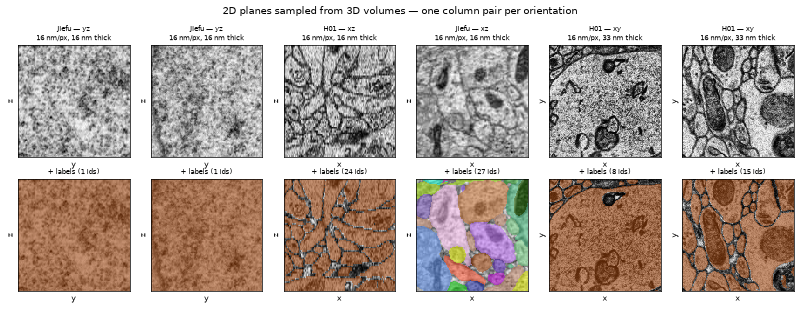

In [10]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams["figure.dpi"] = 64
label_cmap = ListedColormap(np.random.default_rng(0).random((256, 3)))


def show_planes(batch, title):
    n = batch["img"].shape[0]
    fig, axes = plt.subplots(2, n, figsize=(2.1 * n, 4.8))
    for i in range(n):
        img = batch["img"][i, 0, 0].float().numpy()      # (L, C, H, W) -> (H, W)
        lbl = batch["label"][i, 0].numpy()
        plane = batch["plane"][i]
        extent = (batch["bbox"][i, 0, 1] - batch["bbox"][i, 0, 0]).tolist()
        thick = extent[spatial_order.index(batch["normal_axis"][i])]
        res = batch["pixel_size"][i, 0].tolist()

        axes[0, i].imshow(img.T, cmap="gray", origin="lower", interpolation="nearest")
        axes[0, i].set_title(f"{batch['meta']['volume'][i].split()[0]} — {plane}\n"
                             f"{res[0]:g} nm/px, {thick:g} nm thick", fontsize=8)
        axes[1, i].imshow(img.T, cmap="gray", origin="lower", interpolation="nearest")
        axes[1, i].imshow(np.ma.masked_where(lbl == 0, lbl % 256).T, cmap=label_cmap,
                          origin="lower", alpha=0.55, interpolation="nearest")
        axes[1, i].set_title(f"+ labels ({np.unique(lbl).size} ids)", fontsize=8)
        for row in (0, 1):
            axes[row, i].set_xlabel(plane[0], fontsize=9)
            axes[row, i].set_ylabel(plane[1], fontsize=9)
            axes[row, i].set_xticks([])
            axes[row, i].set_yticks([])
    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    plt.show()


# Two samples from each orientation, in a fixed yz / xz / xy order.
show_planes(collate_2d([ds[i] for ds in plane_datasets.values() for i in range(2)]),
            "2D planes sampled from 3D volumes — one column pair per orientation")

## 5. What "one voxel thick" actually means

A one-voxel-thick output is still read as a whole number of *stored* voxels, so the plane has a real
physical thickness of `ceil(target / level_voxel) × level_voxel` along its normal — rounded up, and
**not** the requested `pixel_size`. `bbox` reports the footprint actually covered, so compare the two:

In [11]:
rows = []
for ax, ds in plane_datasets.items():
    for _ in range(6):
        s = ds[0]
        thin = spatial_order.index(ax)
        extent = (s["bbox"][0, 1] - s["bbox"][0, 0]).tolist()
        rows.append((s["meta"]["volume"].split()[0], ax,
                     s["pixel_size"][0, thin].item(), extent[thin]))

print(f"{'volume':<7} {'normal':>6} {'pixel_size':>11} {'thickness':>10} {'ratio':>6}")
seen = set()
for vol, ax, res, thick in rows:
    if (vol, ax) in seen:
        continue
    seen.add((vol, ax))
    print(f"{vol:<7} {ax:>6} {res:>9g} nm {thick:>7g} nm {thick / res:>6.2f}")

volume  normal  pixel_size  thickness  ratio
Jiefu        x        16 nm      16 nm   1.00
H01          x        16 nm      16 nm   1.00
Jiefu        y        16 nm      16 nm   1.00
H01          y        16 nm      16 nm   1.00
H01          z        16 nm      33 nm   2.06
Jiefu        z        16 nm      16 nm   1.00


H01 is stored at 4×4×33 nm, so a 16 nm `xy` plane (`z`-normal) is really a **33 nm** slab — one stored
`z` voxel, because `ceil(16/33) = 1`. Jiefu is 16 nm isotropic, so at a 16 nm target its planes are
exact stored slices.

Note that the ratio above does *not* tell you whether interpolation happened. H01's `yz`/`xz` planes
come out at ratio 1.00, but they get there by reading **4** stored 4 nm voxels and resampling them to
one — a point sample at the middle of the slab, not an average through it. Conversely H01's `xy` plane
has ratio 2.06 and is a single stored section in depth — though still downsampled in-plane. What matters is the read count along the
normal, `ceil(target / level_voxel)`, which the dataset summary prints as the first entry of
`read [...]`.

Two consequences worth knowing before training on this:

- **The orientations are not equivalent on anisotropic data.** For H01, `xy` planes are real stored
  sections while `xz`/`yz` planes are largely interpolated along `z`.
- **Labels are resampled with nearest-neighbor, images with trilinear.** For a one-voxel output,
  nearest takes the *first* plane of the slab and trilinear the *middle* one, so when the thin axis is
  resampled the label plane can come from a slightly different depth than the image plane.

To get an exact stored slice, request a thin-axis resolution no coarser than the stored voxel size on
that axis, so the read count is 1. Resolutions are per-axis, so that is independent of the in-plane
resolution. This removes the *image*'s depth interpolation. It does not by itself fix the image/label offset, because the label read count is resolved from the label pyramid independently: H01's labels are stored at half the image resolution, so a 4 nm image plane sits inside an 8 nm label voxel. Check both read counts if the alignment matters.

In [12]:
# H01 is 4x4x33 nm. Pin x to 4 nm (its stored size) and keep 16 nm in-plane:
#   read along x = ceil(1 * 4 / 4) = 1  ->  a single stored x plane, no interpolation in depth.
exact = with_overrides(
    plane_base,
    volumes=[v for v in plane_base.model_dump()["volumes"] if v["name"].startswith("H01")],
    resolutions=[[4, 16, 16]],
)
exact_ds = VolumeDataset(plane_config(exact, "x", P))

s = exact_ds[0]
extent = (s["bbox"][0, 1] - s["bbox"][0, 0]).tolist()
print(f"\npixel_size = {s['pixel_size'][0].tolist()}")
print(f"thickness  = {extent[spatial_order.index('x')]:g} nm  (one stored 4 nm x voxel)")

VolumeDataset: 1 volume(s), random, 20 samples/epoch, patch_size=[1, 128, 128]
  [H01 Human Cortex]
    image: axes='xyz', shape=[16384, 16384, 1024], dtype=uint8
    scale 0: resolution=[4.0, 16.0, 16.0] nanometer -> level 0 (voxel_size=[4.0, 4.0, 33.0], read [1, 512, 63] -> resample to [1, 128, 128])
    label: axes='xyz', shape=[8192, 8192, 1024], dtype=uint64 -> int64
    sampling: weight=1.00, center_range=[[0, 256, 31], [16382, 16128, 992]]
    normalize: uint8 -> [0, 1] (divide by dtype max)
  output: axes='lcxyz', tensor_shape=(L, C, X, Y, Z)

pixel_size = [4.0, 16.0, 16.0]
thickness  = 4 nm  (one stored 4 nm x voxel)


## 6. Multi-scale planes

In [13]:
multiscale_base = with_overrides(
    plane_base,
    resolutions=[[16, 16, 16], [32, 32, 32], [64, 64, 64]],
)
multiscale = ConcatDataset(
    [VolumeDataset(plane_config(multiscale_base, ax, P)) for ax in spatial_order]
)

ms = next(iter(DataLoader(multiscale, batch_size=4, shuffle=True, collate_fn=collate_2d)))
print("img       ", tuple(ms["img"].shape), "  (B, L, C, H, W)")
print("pixel_size", tuple(ms["pixel_size"].shape))
print("plane     ", ms["plane"])

VolumeDataset: 2 volume(s), random, 20 samples/epoch, patch_size=[1, 128, 128]
  [Jiefu Cerebellum FIB-SEM]
    image: axes='zyx', shape=[11402, 5666, 4808], dtype=uint8
    scale 0: resolution=[16.0, 16.0, 16.0] nanometer -> level 0 (voxel_size=[16.0, 16.0, 16.0], read [128, 128, 1] -> resample to [128, 128, 1])
    scale 1: resolution=[32.0, 32.0, 32.0] nanometer -> level 1 (voxel_size=[32.0, 32.0, 32.0], read [128, 128, 1] -> resample to [128, 128, 1])
    scale 2: resolution=[64.0, 64.0, 64.0] nanometer -> level 2 (voxel_size=[64.0, 64.0, 64.0], read [128, 128, 1] -> resample to [128, 128, 1])
    label: axes='zyx', shape=[11402, 5666, 4808], dtype=uint32 -> int64
    sampling: weight=0.50, center_range=[[1457, 1717, 1136], [5305, 4517, 4804]]
    normalize: uint8 -> [0, 1] (divide by dtype max)
  [H01 Human Cortex]
    image: axes='xyz', shape=[16384, 16384, 1024], dtype=uint8
    scale 0: resolution=[16.0, 16.0, 16.0] nanometer -> level 0 (voxel_size=[4.0, 4.0, 33.0], read [4, 51

img        (4, 3, 1, 128, 128)   (B, L, C, H, W)
pixel_size (4, 3, 3)
plane      ['xz', 'xz', 'xz', 'yz']


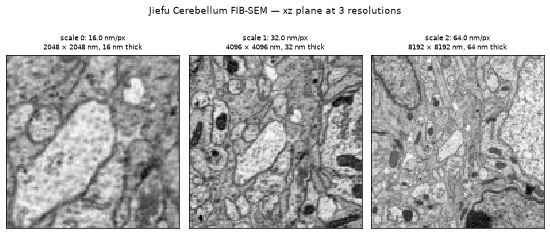

In [14]:
i = 0
n_scales = ms["img"].shape[1]
fig, axes = plt.subplots(1, n_scales, figsize=(2.9 * n_scales, 3.7))
for l in range(n_scales):
    extent = (ms["bbox"][i, l, 1] - ms["bbox"][i, l, 0]).tolist()
    in_plane = [extent[spatial_order.index(c)] for c in ms["plane"][i]]
    thick = extent[spatial_order.index(ms["normal_axis"][i])]
    axes[l].imshow(ms["img"][i, l, 0].float().numpy().T, cmap="gray",
                   origin="lower", interpolation="nearest")
    axes[l].set_title(f"scale {l}: {ms['pixel_size'][i, l, 0]:.1f} nm/px\n"
                      f"{in_plane[0]:.0f} × {in_plane[1]:.0f} nm, {thick:g} nm thick", fontsize=8)
    axes[l].set_xticks([])
    axes[l].set_yticks([])
fig.suptitle(f"{ms['meta']['volume'][i]} — {ms['plane'][i]} plane at "
             f"{n_scales} resolutions", fontsize=10)
fig.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

The scales are concentric but, because each one quantizes the shared centre onto its own voxel grid,
they are not exactly coplanar — coarser planes are offset along the normal by up to roughly half their
own slab thickness (measured up to 28 nm for a 64 nm-thick scale), and their slabs are thicker. Note also that the coarser planes here are not always
lower-resolution *views of the same section*; on strongly anisotropic data several scales can collapse
onto one stored section.

## Notes and caveats

- **Epoch length and mixture.** `ConcatDataset` concatenates, so `len` is the sum and each orientation
  contributes its own `samples_per_epoch`. Set them unequally to bias the mixture, *e.g.* fewer `xz`/`yz`
  planes for strongly anisotropic data, where those planes are mostly interpolation.
- **Cache.** Every `VolumeDataset` builds its own TensorStore context with `cache_bytes` per worker, so
  this pattern triples the cache footprint. Divide `cache_bytes` by three to keep it constant.
- **`rot90isocube` is unavailable for 2D datasets.** It requires a cubic `patch_size` across `x`, `y`, `z`, which a
  one-thick patch is not, so config validation rejects it. Flip and transpose the collated planes
  yourself. Note that mixing the three orientations is already a form of that augmentation.
- **Sequential mode.** `sampling: "sequential"` works and is useful for dense 2D inference over a
  volume. The grid steps one output plane's worth of extent along the normal, which is one stored plane
  only when the read count there is 1; otherwise the stride can be shorter than the plane is thick.
  The default scalar `overlap: 0` is fine, but any non-zero scalar fails validation; use a per-axis
  list with `0` on the thin axis.
- **Label IDs are not trustworthy after resampling.** `miao` casts labels to `float32` before
  resampling them, so IDs above 2^24 are rounded (most of H01's `uint64` IDs change value). Region
  *shapes* survive (a constant region maps to a constant value), so the overlays above are sound, but
  do not rely on the ID numbers themselves.
- **Cost.** A plane patch is far cheaper to read than a cubic one of the same width, but a coarse plane
  on an anisotropic volume can still read far more than it returns, because a pyramid level is only
  eligible when its voxel size is `≤` the target on *every* axis.